In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from PIL import Image
import os
import random
import matplotlib.pyplot as plt

In [3]:
input_dir = "Normal_Images"
output_dir = "binary_images"

# Create output folder
os.makedirs(output_dir, exist_ok=True)

# Image size used by the model
IMG_SIZE = (224, 224)

# Supported image formats
image_extensions = (
    ".jpg",
    ".jpeg",
    ".png"
)

print("Input directory:", input_dir)
print("Output directory:", output_dir)
print("Image size:", IMG_SIZE)

Input directory: Normal_Images
Output directory: binary_images
Image size: (224, 224)


In [4]:
files = [
    f for f in os.listdir(input_dir)
    if f.lower().endswith(image_extensions)
]

print("Total images found:", len(files))

Total images found: 226


In [5]:
X_list = []
y_list = []

THRESHOLD = 127

for filename in files:

    image_path = os.path.join(
        input_dir,
        filename
    )

    # Open normal RGB image
    image = Image.open(image_path).convert("RGB")

    # Resize image
    image = image.resize(IMG_SIZE)

    # Convert to NumPy array
    image_array = np.array(image).astype(np.float32)

    # -----------------------------
    # Input: RGB values
    # -----------------------------
    pixels = image_array.reshape(-1, 3)

    # -----------------------------
    # Create grayscale values
    # -----------------------------
    grayscale = (
        0.299 * pixels[:, 0] +
        0.587 * pixels[:, 1] +
        0.114 * pixels[:, 2]
    )

    # -----------------------------
    # Create binary target
    # -----------------------------
    binary = (grayscale > THRESHOLD).astype(np.float32)

    # Store RGB pixels and binary labels
    X_list.append(pixels)
    y_list.append(binary.reshape(-1, 1))


# Combine all images
X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)

print("Input shape:", X.shape)
print("Target shape:", y.shape)

Input shape: (11339776, 3)
Target shape: (11339776, 1)


In [6]:
X = X / 255.0

print("Minimum RGB value:", X.min())
print("Maximum RGB value:", X.max())

Minimum RGB value: 0.0
Maximum RGB value: 1.0


In [7]:
model = Sequential([

    Dense(
        1,activation="sigmoid",input_shape=(3,)
    )
])

model.summary()

d:\Malaria Plasmodium Parasites\.conda\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

history = model.fit(
    X,
    y,
    epochs=10,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

Model compiled successfully!
Epoch 1/10
35437/35437 ━━━━━━━━━━━━━━━━━━━━ 138s 4ms/step - accuracy: 0.9789 - loss: 0.1426 - val_accuracy: 0.9947 - val_loss: 0.0704
Epoch 2/10
35437/35437 ━━━━━━━━━━━━━━━━━━━━ 67s 2ms/step - accuracy: 0.9952 - loss: 0.0510 - val_accuracy: 0.9967 - val_loss: 0.0504
Epoch 3/10
35437/35437 ━━━━━━━━━━━━━━━━━━━━ 83s 2ms/step - accuracy: 0.9966 - loss: 0.0397 - val_accuracy: 0.9973 - val_loss: 0.0421
Epoch 4/10
35437/35437 ━━━━━━━━━━━━━━━━━━━━ 90s 3ms/step - accuracy: 0.9971 - loss: 0.0341 - val_accuracy: 0.9978 - val_loss: 0.0371
Epoch 5/10
35437/35437 ━━━━━━━━━━━━━━━━━━━━ 103s 3ms/step - accuracy: 0.9974 - loss: 0.0306 - val_accuracy: 0.9975 - val_loss: 0.0339
Epoch 6/10
35437/35437 ━━━━━━━━━━━━━━━━━━━━ 101s 3ms/step - accuracy: 0.9976 - loss: 0.0281 - val_accuracy: 0.9979 - val_loss: 0.0313
Epoch 7/10
35437/35437 ━━━━━━━━━━━━━━━━━━━━ 98s 3ms/step - accuracy: 0.9978 - loss: 0.0262 - val_accuracy: 0.9980 - val_loss: 0.0293
Epoch 8/10
35437/35437 ━━━━━━━━━━━━━━

In [ ]:
loss, accuracy = model.evaluate(
    X,
    y,
    verbose=0
)

print("Final Loss:", loss)
print("Final Accuracy:", accuracy)

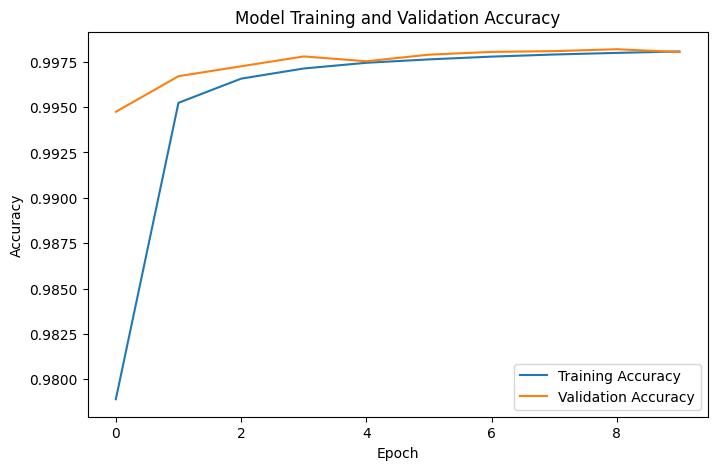

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Training and Validation Accuracy")

plt.legend()
plt.show()

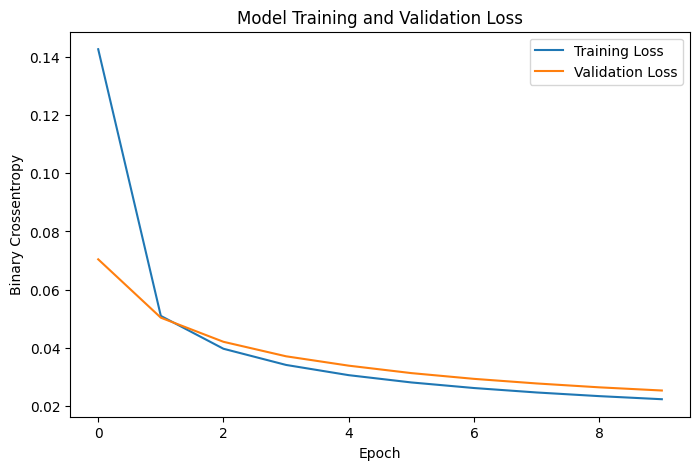

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy")

plt.title("Model Training and Validation Loss")

plt.legend()
plt.show()

In [12]:
def convert_to_binary(model, image_path, output_path):

    # Open normal RGB image
    image = Image.open(image_path).convert("RGB")

    # Resize the new image
    image = image.resize(IMG_SIZE)

    # Convert image to NumPy array
    image_array = np.array(image).astype(np.float32)

    # Get dimensions
    height, width, channels = image_array.shape

    # Convert image into individual RGB pixels
    pixels = image_array.reshape(-1, 3)

    # Normalize RGB values
    pixels_normalized = pixels / 255.0

    # Predict probability of white class
    predictions = model.predict(
        pixels_normalized,
        verbose=0
    )

    # Convert probabilities into binary values
    binary_pixels = (predictions >= 0.5).astype(np.uint8)

    # Convert 0/1 into 0/255
    binary_pixels = binary_pixels * 255

    # Reshape pixels back into image
    binary_image = binary_pixels.reshape(
        height,
        width
    )

    # Save binary image
    Image.fromarray(binary_image).save(
        output_path
    )

    return image_array, binary_image

Image 1 saved at: binary1.jpg
Image 2 saved at: binary2.jpg


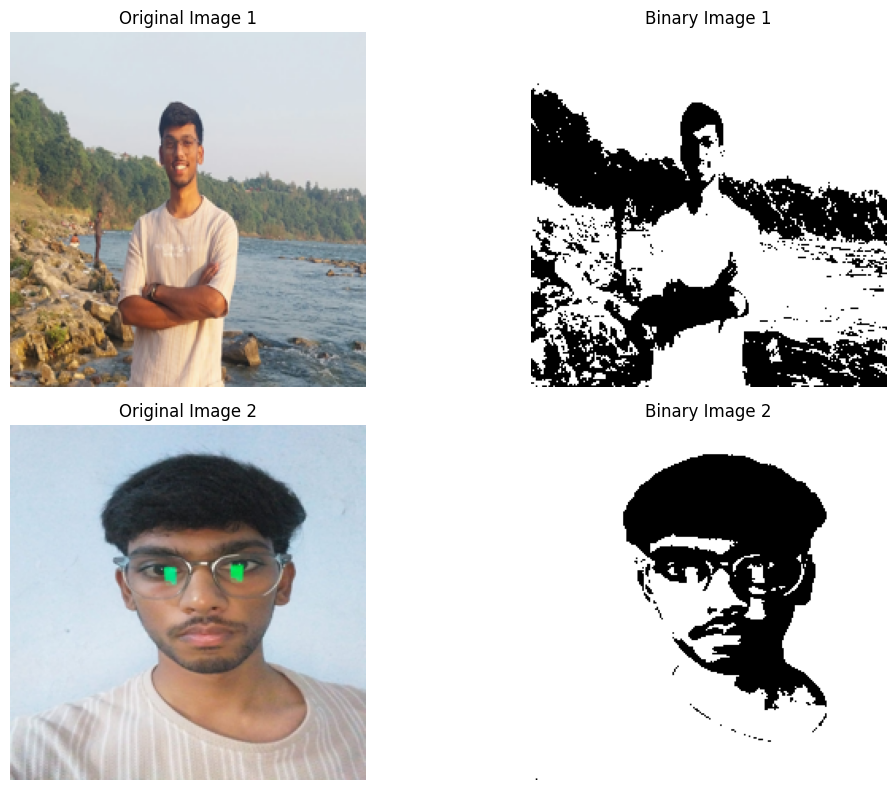

In [13]:
test_image_paths = [
    "img1.jpeg",
    "img2.jpeg"
]

test_output_paths = [
    "binary1.jpg",
    "binary2.jpg"
]

plt.figure(figsize=(12, 8))

for i in range(2):

    # Convert image using trained model
    original_image, binary_image = convert_to_binary(
        model,
        test_image_paths[i],
        test_output_paths[i]
    )

    # Original image
    plt.subplot(2, 2, 2*i + 1)

    plt.imshow(
        original_image.astype(np.uint8)
    )

    plt.title(f"Original Image {i+1}")
    plt.axis("off")

    # Binary image
    plt.subplot(2, 2, 2*i + 2)

    plt.imshow(
        binary_image,
        cmap="gray"
    )

    plt.title(f"Binary Image {i+1}")
    plt.axis("off")

    print(
        f"Image {i+1} saved at: "
        f"{test_output_paths[i]}"
    )

plt.tight_layout()
plt.show()